In [1]:
using Revise
using PVlib

using HTTP
using JSON
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones

[ Info: Precompiling PVlib [7b90ca13-13a1-463a-b450-7b420c616eff] (cache misses: include_dependency fsize change (6), mismatched flags (10))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
latitude = 35.1
longitude = -106.6
altitude = 1500.0 # m

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

number_of_panels = 1
orientation = 180

180

In [3]:
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

println(weather_data)

WeatherSample × 24
time                       ghi    dni    dhi   temp_air             temp_dew             relative_humidity  pressure  wind_speed          wind_direction  albedo
─────────────────────────  ─────  ─────  ────  ───────────────────  ───────────────────  ─────────────────  ────────  ──────────────────  ──────────────  ──────
2020-01-01T00:00:00-07:00  0.0    0.0    0.0   -3.0                 -9.200000000000001   missing            836.0     1.6                 324.0           0.16  
2020-01-01T01:00:00-07:00  0.0    0.0    0.0   -3.5                 -9.600000000000001   missing            835.0     1.6                 327.0           0.16  
2020-01-01T02:00:00-07:00  0.0    0.0    0.0   -4.0                 -9.9                 missing            835.0     1.5                 333.0           0.16  
2020-01-01T03:00:00-07:00  0.0    0.0    0.0   -4.5                 -10.200000000000001  missing            835.0     1.5                 336.0           0.16  
2020-01-01T04:0

In [4]:
surface_tilt = latitude
surface_azimuth = 180.0

albedo = 0.25
total_irradiance = get_total_irradiance(surface_tilt, surface_azimuth, weather_data, sol_position, albedo) # verified same

println(total_irradiance)

LoadError: UndefVarError: `sol_position` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:

module_filename = "sam-library-sandia-modules-2015-6-30.csv"
module_name = "Canadian Solar CS5P-220M [ 2009]"  # "BP Solar SX305 [2007 (E)]"

inverter_filename = "sam-library-cec-inverters-2019-03-05.csv"
inverter_name = "ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # "SMA America: SB 240-US-10 [240V]"

pv_module = read_solar_module(module_name, module_filename)
pv_inverter = read_solar_inverter(inverter_name, inverter_filename)

println(pv_module)
println(pv_inverter)

SolarModule
────────────
name               │ Canadian Solar CS5P-220M [ 2009]
vintage            │ 2009
area               │ 1.701
material           │ c-Si
cells_in_series    │ 96
parallel_strings   │ 1
isco               │ 5.09115
voco               │ 59.2608
impo               │ 4.54629
vmpo               │ 48.3156
aisc               │ 0.000397
aimp               │ 0.000181
c0                 │ 1.01284
c1                 │ -0.0128398
bvoco              │ -0.21696
mbvoc              │ 0.0
bvmpo              │ -0.235488
mbvmp              │ 0.0
n                  │ 1.4032
c2                 │ 0.279317
c3                 │ -7.24463
a0                 │ 0.928385
a1                 │ 0.068093
a2                 │ -0.0157738
a3                 │ 0.0016606
a4                 │ -6.93e-5
b0                 │ 1.0
b1                 │ -0.002438
b2                 │ 0.0003103
b3                 │ -1.246e-5
b4                 │ 2.11e-7
b5                 │ -1.36e-9
dtc                │ 3.0
fd  

In [ ]:
module_temp = sapm_module_temperature(total_irradiance, weather_data)
cell_temp = sapm_cell_temperature(total_irradiance, weather_data) # verified same
println(module_temp)
println(cell_temp) 

ModuleTemperature × 24
time                       module_temperature 
─────────────────────────  ───────────────────
2020-01-01T00:00:00-07:00  -2.998823208530198 
2020-01-01T01:00:00-07:00  -3.498823208530198 
2020-01-01T02:00:00-07:00  -3.99881619758698  
2020-01-01T03:00:00-07:00  -4.49881619758698  
2020-01-01T04:00:00-07:00  -4.798816197586981 
2020-01-01T05:00:00-07:00  -5.19881619758698  
2020-01-01T06:00:00-07:00  -5.19881619758698  
2020-01-01T07:00:00-07:00  -0.5075006151430377
2020-01-01T08:00:00-07:00  9.618698891231691  
2020-01-01T09:00:00-07:00  18.00053681470248  
… (14 more rows)

CellTemperature × 24
time                       cell_temperature    
─────────────────────────  ────────────────────
2020-01-01T00:00:00-07:00  -2.998698442037697  
2020-01-01T01:00:00-07:00  -3.498698442037697  
2020-01-01T02:00:00-07:00  -3.998691431094479  
2020-01-01T03:00:00-07:00  -4.498691431094479  
2020-01-01T04:00:00-07:00  -4.79869143109448   
2020-01-01T05:00:00-07:00  -5.19869143

In [ ]:
effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, surface_tilt, surface_azimuth, altitude) # verified same
println(effective_irradiance)

EffectiveIrradiance × 24
time                       effective_irradiance
─────────────────────────  ────────────────────
2020-01-01T00:00:00-07:00  0.0                 
2020-01-01T01:00:00-07:00  0.0                 
2020-01-01T02:00:00-07:00  0.0                 
2020-01-01T03:00:00-07:00  0.0                 
2020-01-01T04:00:00-07:00  0.0                 
2020-01-01T05:00:00-07:00  0.0                 
2020-01-01T06:00:00-07:00  0.0                 
2020-01-01T07:00:00-07:00  0.0                 
2020-01-01T08:00:00-07:00  401.36877151314064  
2020-01-01T09:00:00-07:00  659.8901361841657   
… (14 more rows)



In [ ]:
dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)
println(dc_components)

DCComponents × 24
time                       i_sc               i_mp               v_oc                v_mp                p_mp               i_x                 i_xx              
─────────────────────────  ─────────────────  ─────────────────  ──────────────────  ──────────────────  ─────────────────  ──────────────────  ──────────────────
2020-01-01T00:00:00-07:00  0.0                0.0                51.918072550153134  37.57573193177046   0.0                0.0                 0.0               
2020-01-01T01:00:00-07:00  0.0                0.0                52.05138553260862   37.75065429747954   0.0                0.0                 0.0               
2020-01-01T02:00:00-07:00  0.0                0.0                52.1846966457646    37.92548113747091   0.0                0.0                 0.0               
2020-01-01T03:00:00-07:00  0.0                0.0                52.31800962822008   38.100217354617484  0.0                0.0                 0.0               
2020

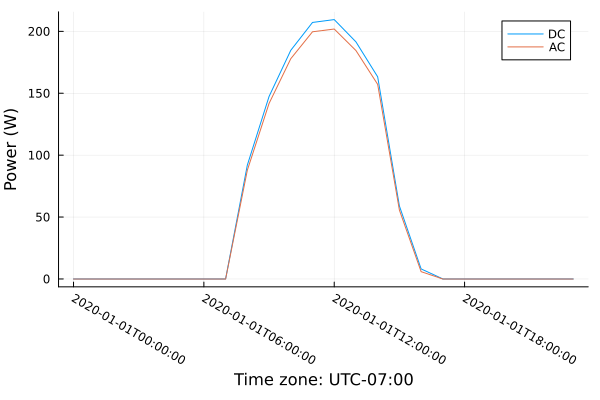

In [ ]:
ac_power = sandia_ac_power(pv_inverter, dc_components) # verified same

plot(getfield.(dc_components, :time), getfield.(dc_components, :p_mp), label="DC", xlabel="Time", ylabel="Power (W)", legend=:topright, xrotation=-30, bottom_margin=8Plots.mm,)
plot!(getfield.(ac_power, :time), getfield.(ac_power, :ac_power), label="AC")

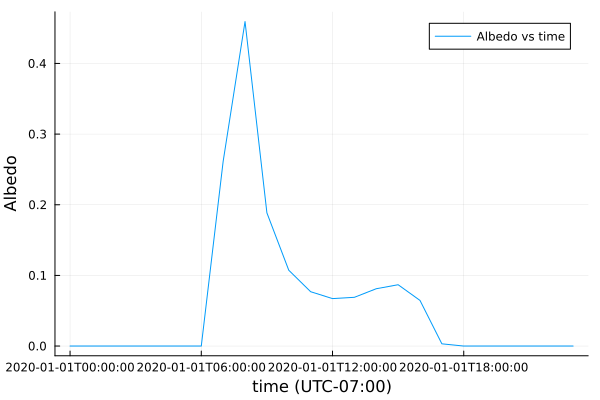

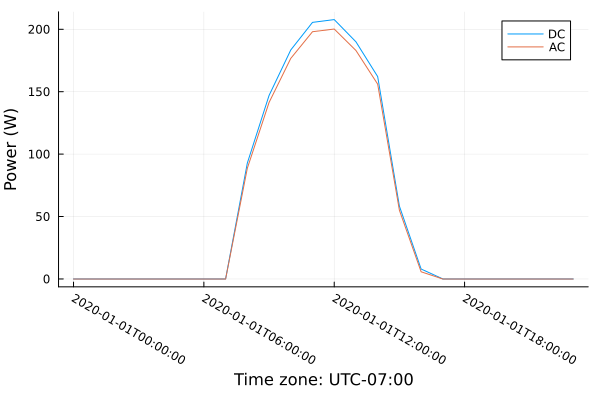

In [ ]:
# try with ocean surface albedo
albedo = get_ocean_surface_albedo(weather_data, sol_position)
p1 = plot(getfield.(weather_data, :time), albedo, label="Albedo vs time", xlabel="time", ylabel="Albedo", legend=:topright)
display(p1)

total_irradiance = get_total_irradiance(surface_tilt, surface_azimuth, weather_data, sol_position, albedo)
module_temp = sapm_module_temperature(total_irradiance, weather_data)
cell_temp = sapm_cell_temperature(total_irradiance, weather_data) # verified same
effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, surface_tilt, surface_azimuth, altitude) # verified same
dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)
ac_power = sandia_ac_power(pv_inverter, dc_components) # verified same  

p2 = plot(getfield.(dc_components, :time), getfield.(dc_components, :p_mp), label="DC", xlabel="Time", ylabel="Power (W)", legend=:topright, xrotation=-30, bottom_margin=8Plots.mm,)
p2 = plot!(getfield.(ac_power, :time), getfield.(ac_power, :ac_power), label="AC")
display(p2)